# MedScan Diagnostics — Blood Cell Detection with YOLO
**Dataset:** BCCD (Blood Cell Count and Detection)  
**Model:** YOLOv8 (Ultralytics) 
**Classes:** RBC (Red Blood Cell), WBC (White Blood Cell), Platelet  
**Objective:** Train an object detection model, evaluate performance, and assess clinical deployment viability.

## 1. Install Dependencies

In [1]:
# Install required packages
%pip install -r ../requirements.txt --quiet

import ultralytics
ultralytics.checks()


Ultralytics 8.4.19  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
Setup complete  (12 CPUs, 15.9 GB RAM, 340.0/464.9 GB disk)


## 2. Import Libraries

In [2]:
import os
import yaml
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
from IPython.display import display, Image

from ultralytics import YOLO
from roboflow import Roboflow

# Set seeds for reproducibility
random.seed(42)
np.random.seed(42)

print("All libraries imported successfully.")


All libraries imported successfully.


## 3. Load the BCCD Dataset from Roboflow

> **Instructions:**  
> 1. Create a free account at [roboflow.com](https://roboflow.com)  
> 2. Go to [Roboflow Universe — BCCD Dataset](https://universe.roboflow.com/roboflow-100/bccd-ue3dp)  
> 3. Click **Download** → choose **YOLOv8** format → select **Show Download Code**  
> 4. Copy your API key and paste it below

In [4]:
# -------------------------------------------------------
# REPLACE with your Roboflow API key
ROBOFLOW_API_KEY = "3gbxQ0DCCQhhl4BVojvG"
# -------------------------------------------------------

rf = Roboflow(api_key=ROBOFLOW_API_KEY)

# Load the BCCD dataset (YOLOv8 format)
project = rf.workspace("joseph-nelson").project("bccd")
version = project.version(3)
dataset = version.download("yolov8")

print(f"Dataset downloaded to: {dataset.location}")

loading Roboflow workspace...
loading Roboflow project...
Dataset downloaded to: c:\Users\jchen\MiniProject7-BloodCellDetection\notebooks\BCCD-3


## 4. Verify Dataset Structure

In [5]:
# Print dataset directory structure
dataset_path = Path(dataset.location)

for split in ["train", "valid", "test"]:
    images = list((dataset_path / split / "images").glob("*")) if (dataset_path / split / "images").exists() else []
    labels = list((dataset_path / split / "labels").glob("*")) if (dataset_path / split / "labels").exists() else []
    print(f"{split:>6}: {len(images):>4} images | {len(labels):>4} labels")

# Show data.yaml contents
yaml_path = dataset_path / "data.yaml"
with open(yaml_path, "r") as f:
    data_config = yaml.safe_load(f)

print("\n--- data.yaml ---")
print(yaml.dump(data_config, default_flow_style=False))

 train:  255 images |  255 labels
 valid:   73 images |   73 labels
  test:   36 images |   36 labels

--- data.yaml ---
names:
- Platelets
- RBC
- WBC
nc: 3
roboflow:
  license: MIT
  project: bccd
  url: https://universe.roboflow.com/joseph-nelson/bccd/dataset/3
  version: 3
  workspace: joseph-nelson
test: ../test/images
train: ../train/images
val: ../valid/images



## 5. Visualize Sample Training Images

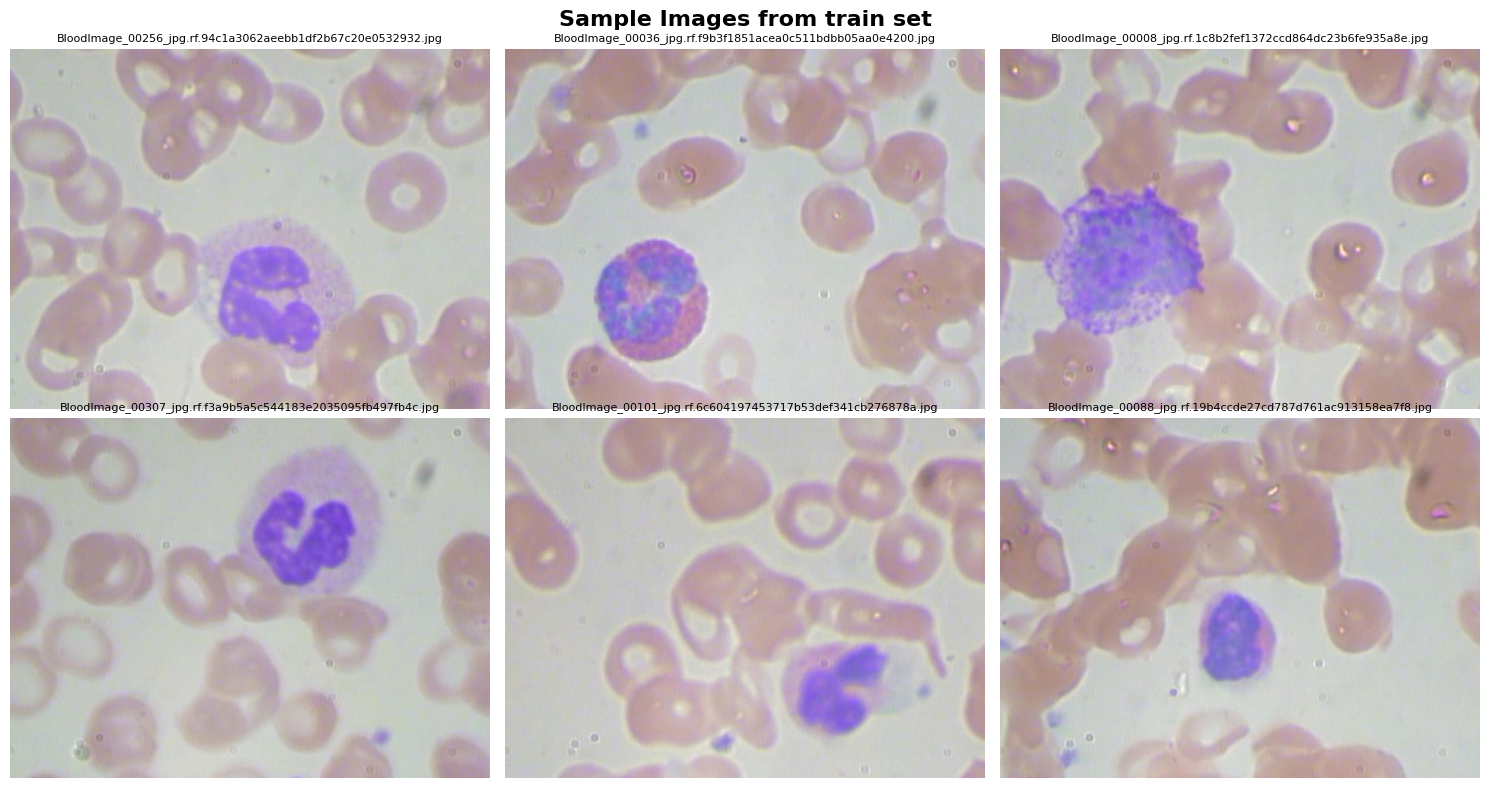

Saved: sample_images.png


In [5]:
def plot_sample_images(dataset_path, split="train", n=6):
    """Display a grid of sample images from the dataset."""
    images_dir = Path(dataset_path) / split / "images"
    image_files = list(images_dir.glob("*.jpg")) + list(images_dir.glob("*.png"))
    sample = random.sample(image_files, min(n, len(image_files)))

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(f"Sample Images from {split} set", fontsize=16, fontweight="bold")

    for ax, img_path in zip(axes.flatten(), sample):
        img = mpimg.imread(img_path)
        ax.imshow(img)
        ax.set_title(img_path.name, fontsize=8)
        ax.axis("off")

    plt.tight_layout()
    plt.savefig("sample_images.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: sample_images.png")

plot_sample_images(dataset.location, split="train")

## 6. Load Pre-trained YOLO Model (COCO Weights)

In [6]:
# Load YOLOv8 small model pre-trained on COCO
# Options: yolov8n.pt (nano, fastest) | yolov8s.pt (small, better accuracy)
model = YOLO("yolov8s.pt")

print("Model loaded successfully.")
print(f"Model type: {type(model)}")
model.info()

Model loaded successfully.
Model type: <class 'ultralytics.models.yolo.model.YOLO'>
YOLOv8s summary: 129 layers, 11,166,560 parameters, 0 gradients, 28.8 GFLOPs


(129, 11166560, 0, 28.816844800000002)

## 7. Train the Model

Training configuration:
- **epochs:** 25 (minimum 25 as required)
- **imgsz:** 640
- **batch:** 16
- **Pretrained:** COCO weights (transfer learning)

In [7]:
import torch
print(torch.cuda.is_available())        # should print True
print(torch.cuda.get_device_name(0))    # should print your GPU name

True
NVIDIA GeForce RTX 3060


In [8]:
# Train the model
results = model.train(
    data=str(yaml_path),       # path to data.yaml
    epochs=25,                  # >= 25 as required
    imgsz=640,                  # input image size
    batch=16,                   # batch size (reduce to 8 if GPU memory issues)
    name="bccd_yolov8s",        # experiment name
    project="medscan_runs",     # output folder
    pretrained=True,            # start from COCO weights
    patience=10,                # early stopping patience
    save=True,                  # save checkpoints
    plots=True,                 # auto-generate training plots
    device=0,                   # use GPU (set to 'cpu' if no GPU available)
    verbose=False
)

print("\nTraining complete!")
print(f"Best model saved at: {results.save_dir}")

Ultralytics 8.4.19  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\jchen\MiniProject7-BloodCellDetection\notebooks\BCCD-3\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=bccd_yolov8s2, nbs=64, nms=False, opset=None, optimize=False,

## 8. Evaluate Model Performance

In [12]:
# Load the best trained model
best_model_path = Path("runs/detect/medscan_runs/bccd_yolov8s2/weights/best.pt")
best_model = YOLO(best_model_path)

# Run validation on the validation set
metrics = best_model.val(
    data=str(yaml_path),
    split="val",
    plots=True,
    save_json=True
)

print("\n" + "="*50)
print("EVALUATION RESULTS")
print("="*50)
print(f"mAP@50:       {metrics.box.map50:.4f}")
print(f"mAP@50-95:    {metrics.box.map:.4f}")
print(f"Precision:    {metrics.box.mp:.4f}")
print(f"Recall:       {metrics.box.mr:.4f}")
print("="*50)

Ultralytics 8.4.19  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
Model summary (fused): 73 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 50.86.6 MB/s, size: 20.7 KB)
val: Scanning C:\Users\jchen\MiniProject7-BloodCellDetection\notebooks\BCCD-3\valid\labels.cache... 73 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 73/73  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.1s/it 5.7s0.6s2s
                   all         73        967      0.873      0.897      0.933      0.675
             Platelets         42         76      0.824      0.908      0.908       0.53
                   RBC         72        819      0.829      0.783        0.9      0.652
                   WBC         71         72      0.965          1       0.99      0.843
Speed: 3.4ms preprocess, 7.6ms inference, 0.0ms loss, 5.5ms postprocess per image
Saving C:\